# Importing Libraries

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import recall_score
from pathlib import Path
from sklearn.model_selection import GridSearchCV
import warnings

# Importing data

In [2]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import PROCESSED_DATA_DIR

import pandas as pd

# Load the data
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test_processed.csv")

2025-08-16 07:26:14.619 | INFO     | dm_classif.config:<module>:11 - PROJ_ROOT path is: C:\Users\Vijay\Documents\teams_github\Ricky\demo_dm_proj


# Split features and target

In [3]:
X_train = train_df.drop(columns="Diabetes_binary")
y_train = train_df["Diabetes_binary"]

X_test = test_df.drop(columns="Diabetes_binary")
y_test = test_df["Diabetes_binary"]


# Function to evaluate models

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name=''):
    # Train predictions
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds, average='binary')  # or 'macro' for multi-class
    train_cf = confusion_matrix(y_train, train_preds, normalize='true')
    
    # Test predictions
    test_preds = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds, average='binary')
    test_cf = confusion_matrix(y_test, test_preds, normalize='true')
    
    # Print accuracy and recall
    print(f"{name} Accuracy:")
    print(f"  Train: {train_accuracy * 100:.2f}%")
    print(f"  Test : {test_accuracy * 100:.2f}%")
    print(f"{name} Recall:")
    print(f"  Train: {train_recall * 100:.2f}%")
    print(f"  Test : {test_recall * 100:.2f}%")

    # Print classification report (includes recall too)
    print(f"\n{name} Classification Report (Test):")
    print(classification_report(y_test, test_preds))

    # Plot confusion matrices
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(train_cf, annot=True, ax=axs[0], cmap='Blues')
    axs[0].set_title(f"{name} - Train Confusion Matrix")
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    sns.heatmap(test_cf, annot=True, ax=axs[1], cmap='Greens')
    axs[1].set_title(f"{name} - Test Confusion Matrix")
    axs[1].set_xlabel('Predicted')
    axs[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()



# Dummy Classifier (Baseline Model)

DummyClassifier Accuracy:
  Train: 49.30%
  Test : 48.68%
DummyClassifier Recall:
  Train: 0.00%
  Test : 0.00%

DummyClassifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.49      1.00      0.65      6723
         1.0       0.00      0.00      0.00      7089

    accuracy                           0.49     13812
   macro avg       0.24      0.50      0.33     13812
weighted avg       0.24      0.49      0.32     13812



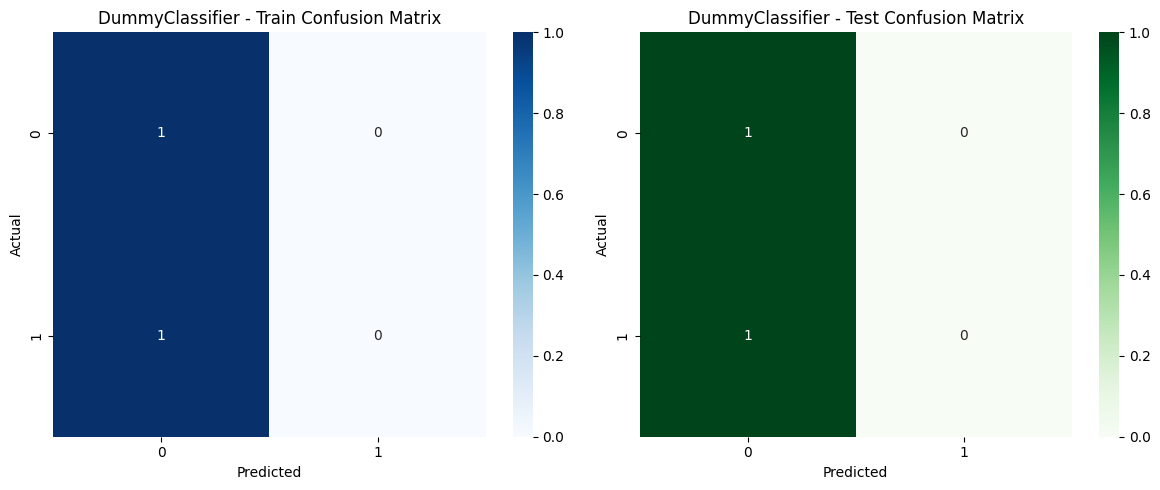

In [6]:
dummy = DummyClassifier(strategy="constant", constant=0)
dummy.fit(X_train, y_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    evaluate_model(dummy, X_train, y_train, X_test, y_test, name='DummyClassifier')

# Logistic Regression

LogisticRegression Accuracy:
  Train: 74.00%
  Test : 74.91%
LogisticRegression Recall:
  Train: 76.69%
  Test : 77.02%

LogisticRegression Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      6723
         1.0       0.75      0.77      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



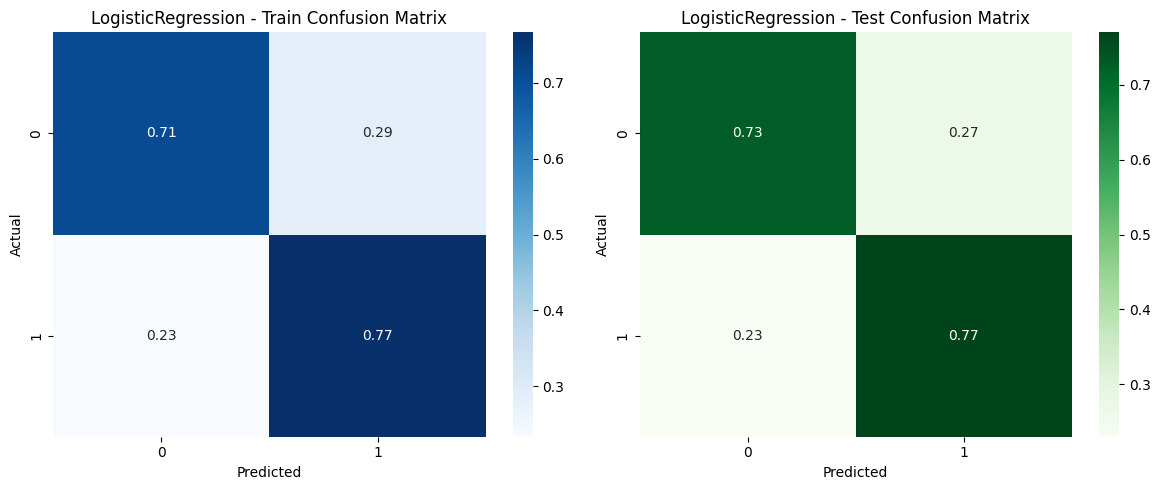

In [7]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
evaluate_model(logreg, X_train, y_train, X_test, y_test, name='LogisticRegression')

# Logistic Regression with tuning

Best Logistic Regression Params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
LogisticRegression Accuracy:
  Train: 73.86%
  Test : 74.83%
LogisticRegression Recall:
  Train: 76.80%
  Test : 77.22%

LogisticRegression Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.74      6723
         1.0       0.75      0.77      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



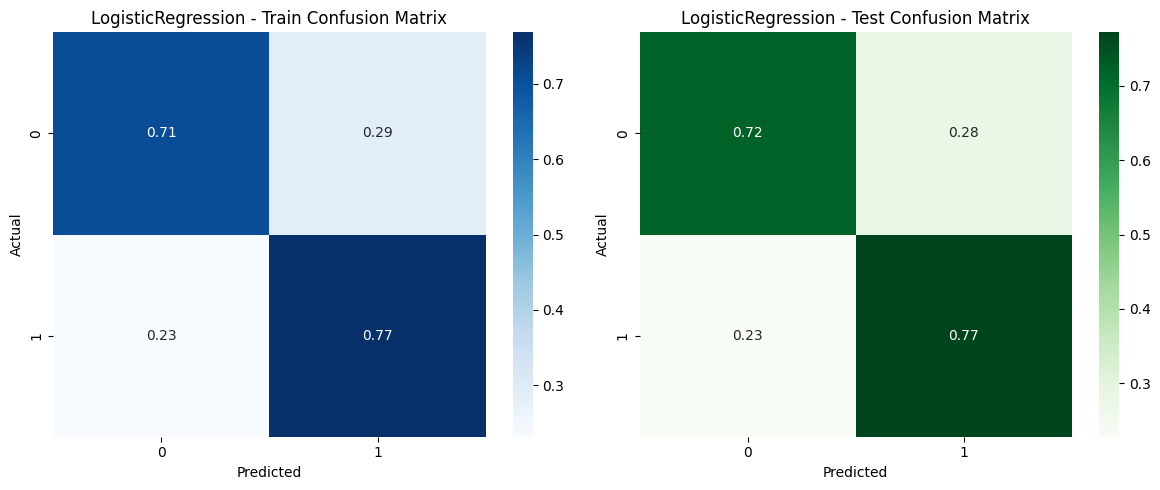

In [8]:
param_grid_logreg = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.3, 0.5, 0.7],
        'C': [0.01, 0.1, 1]
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1]
    }
]

logreg = LogisticRegression(random_state=42)

grid_logreg = GridSearchCV(logreg, param_grid_logreg, cv=5, scoring='recall', n_jobs=-1)
grid_logreg.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_logreg.best_params_)
evaluate_model(grid_logreg.best_estimator_, X_train, y_train, X_test, y_test, name='LogisticRegression')

# Decision Tree Classifier

DecisionTreeClassifier Accuracy:
  Train: 96.47%
  Test : 65.65%
DecisionTreeClassifier Recall:
  Train: 94.12%
  Test : 62.94%

DecisionTreeClassifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.64      0.69      0.66      6723
         1.0       0.68      0.63      0.65      7089

    accuracy                           0.66     13812
   macro avg       0.66      0.66      0.66     13812
weighted avg       0.66      0.66      0.66     13812



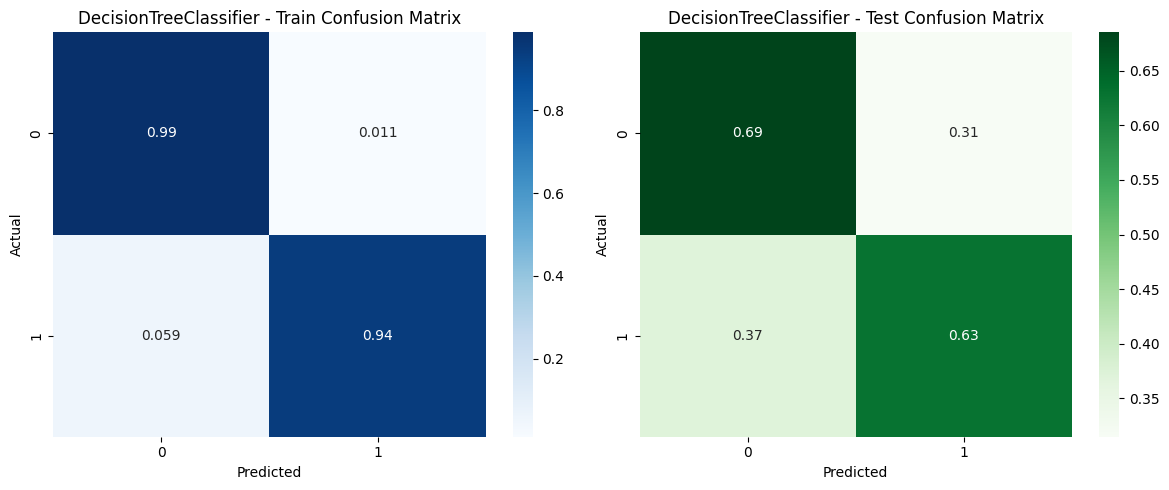

In [10]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
evaluate_model(dtree, X_train, y_train, X_test, y_test, name='DecisionTreeClassifier')

# Decision Tree Tuned

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
DecisionTreeClassifier Accuracy:
  Train: 70.56%
  Test : 71.92%
DecisionTreeClassifier Recall:
  Train: 85.01%
  Test : 85.40%

DecisionTreeClassifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.79      0.58      0.67      6723
         1.0       0.68      0.85      0.76      7089

    accuracy                           0.72     13812
   macro avg       0.73      0.72      0.71     13812
weighted avg       0.73      0.72      0.71     13812



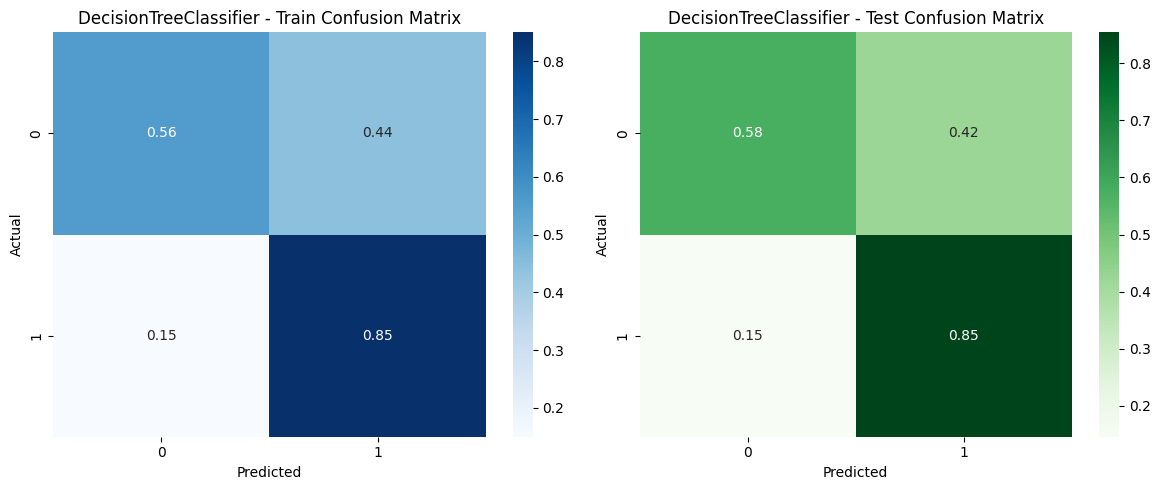

In [11]:
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree = DecisionTreeClassifier(random_state=42)

grid_tree = GridSearchCV(tree, param_grid_tree, cv=5, scoring='recall', n_jobs=-1)
grid_tree.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_tree.best_params_)
evaluate_model(grid_tree.best_estimator_, X_train, y_train, X_test, y_test, name='DecisionTreeClassifier')

# Evaluation

| Model | Training recall | Test recall|
|-------|-------------------|--------------|
|DummyClassifier|0%|0%|
|LogisticRegression|76.69%|77.02%|
|LogisticRegression (Tuned)|76.80%|77.22%|
|DecisionTree|94.12%|62.94%|
|DecisionTree (Tuned)|85.01.60%|85.40%|